# 🤝 5-Fold Multimodal Video + Audio Late Fusion Evaluation Pipeline
### 🏆 Gemastik 2026 Revision 1 Pipeline

This notebook evaluates the 5-Fold fine-tuned **Video ViT (`dima806`)** and **Audio Wav2Vec2 (`MelodyMachine`)** fold models saved in `models/revision1/` using a **50/50 Late Fusion Scheme** ($0.5 \cdot P_{\text{video}} + 0.5 \cdot P_{\text{audio}}$).

### 🔑 Key Methodological Features:
1. **Strict 5-Fold Split Loading (`kfold_splits.json`):** Evaluates exact 5-fold validation splits generated by `generate_kfold_split.ipynb`.
2. **50/50 Multimodal Late Fusion:** Combines Video and Audio probabilities ($P_{\text{multimodal}} = 0.5 \cdot P_{\text{video}} + 0.5 \cdot P_{\text{audio}}$).
3. **5-Fold Cross-Validation Metrics:** Reports 5-Fold Mean $\pm$ Std (Accuracy, Precision, Recall, Macro F1-Score) + Master Out-of-Fold Confusion Matrix.
4. **Independent Held-Out Test Evaluation (Section 10):** Evaluates 5-Fold Multimodal Soft Voting Ensemble on dedicated test archives (`testReal.zip` & `testAI.zip`).

In [2]:
# 1. Setup Environment & Import Libraries
import os
import glob
import shutil
import random
import zipfile
import subprocess
import json
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import AutoImageProcessor, AutoModelForImageClassification, AutoFeatureExtractor, AutoModelForAudioClassification

# Set seeds for 100% reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Execution Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 Active GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB VRAM)")


🖥️ Execution Device: cuda
🎮 Active GPU: NVIDIA L4 (23.66 GB VRAM)


In [3]:
# 2. Setup Base Directory & Drive Paths
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models/revision1"
KFOLD_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/kfold_splits.json"

LOCAL_RAW_DIR = "/content/dataset_raw"
LOCAL_FRAMES_DIR = "/content/dataset_frames_1fps"
LOCAL_AUDIO_DIR = "/content/dataset_audio_16k"
CLASSES = ["Real", "AI"]
SAMPLE_RATE = 16000
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * 5.0)  # 5.0 seconds = 80,000 samples

print(f"📁 Base Model Save Directory: {MODEL_SAVE_DIR}")
print(f"🛡️ 5-Fold Split File: {KFOLD_SPLIT_FILE}")


📁 Base Model Save Directory: /content/drive/MyDrive/Gemastik26/models/revision1
🛡️ 5-Fold Split File: /content/drive/MyDrive/Gemastik26/kfold_splits.json


In [4]:
# 3. Unzip Raw Dataset Archives & Extract Audio & Frames
ZIP_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

def unzip_file(zip_path, extract_to):
    print(f"📦 Unzipping '{zip_path}' -> '{extract_to}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")

for cls, zpath in ZIP_PATHS.items():
    target_dir = os.path.join(LOCAL_RAW_DIR, cls)
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"⏭️ Target directory '{target_dir}' already exists. Skipping unzip.")
    elif os.path.exists(zpath):
        unzip_file(zpath, target_dir)
    else:
        print(f"⚠️ Zip file not found: {zpath}")


⏭️ Target directory '/content/dataset_raw/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw/AI' already exists. Skipping unzip.


In [5]:
# 4. 🛡️ STRICT 5-FOLD SPLIT LOADING (Must be generated by generate_kfold_split.ipynb)
if os.path.exists(KFOLD_SPLIT_FILE):
    with open(KFOLD_SPLIT_FILE, "r", encoding="utf-8") as f:
        kfold_splits = json.load(f)
    print(f"✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:")
    print(f"➡️ {KFOLD_SPLIT_FILE}")
else:
    raise FileNotFoundError(
        f"❌ ERROR: 5-Fold split file not found at: {KFOLD_SPLIT_FILE}\n"
        f"Please execute 'generate_kfold_split.ipynb' first to generate and export kfold_splits.json to Drive!"
    )

print(f"📊 Active Folds Loaded: {list(kfold_splits.keys())}")
for f_name, f_data in kfold_splits.items():
    print(f"   - {f_name}: {len(f_data['train_stems'])} Train Stems | {len(f_data['val_stems'])} Val Stems")


✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:
➡️ /content/drive/MyDrive/Gemastik26/kfold_splits.json
📊 Active Folds Loaded: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
   - fold_1: 853 Train Stems | 214 Val Stems
   - fold_2: 854 Train Stems | 213 Val Stems
   - fold_3: 853 Train Stems | 214 Val Stems
   - fold_4: 854 Train Stems | 213 Val Stems
   - fold_5: 854 Train Stems | 213 Val Stems


In [6]:
# 5. Extract Video Frames (1 FPS) & Audio Tracks (16kHz Mono) for All Dataset Videos
def extract_audio_from_video(video_path, output_wav_path, target_sr=16000):
    cmd = [
        "ffmpeg", "-y", "-i", video_path, "-vn",
        "-acodec", "pcm_s16le", "-ar", str(target_sr), "-ac", "1",
        output_wav_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    if not os.path.exists(output_wav_path) or os.path.getsize(output_wav_path) < 100:
        try:
            y, sr = librosa.load(video_path, sr=target_sr, mono=True)
            sf.write(output_wav_path, y, target_sr)
        except Exception:
            pass

def extract_frames_from_video(video_path, target_fps=1.0, max_frames=30):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    if video_fps <= 0 or np.isnan(video_fps):
        video_fps = 30.0
    frame_interval = max(1, int(round(video_fps / target_fps)))
    frames = []
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame_rgb))
            if len(frames) >= max_frames:
                break
        count += 1
    cap.release()
    return frames

# Pre-extract audio files into LOCAL_AUDIO_DIR
for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    if not os.path.exists(cls_raw_dir):
        continue
    video_files = glob.glob(os.path.join(cls_raw_dir, "**", "*.mp4"), recursive=True)
    print(f"🎙️ Processing 16kHz audio for {len(video_files)} {cls} videos...")
    for vid in tqdm(video_files, desc=f"Audio Extraction [{cls}]"):
        v_stem = Path(vid).stem
        out_wav = os.path.join(cls_audio_dir, f"{v_stem}.wav")
        if not os.path.exists(out_wav) or os.path.getsize(out_wav) < 100:
            extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)

print("✅ Video & Audio Extraction Helpers Ready!")


🎙️ Processing 16kHz audio for 654 Real videos...


Audio Extraction [Real]:   0%|          | 0/654 [00:00<?, ?it/s]/tmp/ipykernel_105905/1266368911.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Extraction [Real]:  10%|▉         | 63/654 [00:00<00:08, 69.39it/s]/tmp/ipykernel_105905/1266368911.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio E

🎙️ Processing 16kHz audio for 413 AI videos...


Audio Extraction [AI]:   0%|          | 0/413 [00:00<?, ?it/s]/tmp/ipykernel_105905/1266368911.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Extraction [AI]:  48%|████▊     | 198/413 [00:00<00:00, 1122.33it/s]/tmp/ipykernel_105905/1266368911.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=target_sr, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Audio Ex

✅ Video & Audio Extraction Helpers Ready!


In [7]:
# 6. Define Feature Processors & Transforms
video_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

feature_extractor = AutoFeatureExtractor.from_pretrained("MelodyMachine/Deepfake-audio-detection-V2")
print("✅ Loaded Video Transforms & Audio Feature Extractor!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


✅ Loaded Video Transforms & Audio Feature Extractor!


In [8]:
# 7. Single Video Modality Predictor Helpers (Memory Optimized)
def predict_video_ai_prob(video_path, video_model, batch_size=16):
    frames = extract_frames_from_video(video_path, target_fps=1.0, max_frames=30)
    if not frames:
        return 0.5  # Neutral fallback
    all_probs = []
    for i in range(0, len(frames), batch_size):
        batch_frames = frames[i:i + batch_size]
        tensors = torch.stack([video_transform(f) for f in batch_frames]).to(device)
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                outputs = video_model(tensors)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.extend(probs[:, 1])  # Index 1 = AI for Video ViT model
        del tensors
        torch.cuda.empty_cache()
    return float(np.mean(all_probs))

def predict_audio_ai_prob(audio_wav_path, audio_model):
    if not os.path.exists(audio_wav_path) or os.path.getsize(audio_wav_path) < 100:
        return 0.5  # Neutral fallback
    try:
        waveform = None
        try:
            waveform, sr = torchaudio.load(audio_wav_path)
        except Exception:
            y, sr = librosa.load(audio_wav_path, sr=SAMPLE_RATE, mono=True)
            waveform = torch.from_numpy(y).unsqueeze(0)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            resampler = T.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        total_len = waveform.shape[-1]
        chunks = []
        if total_len <= MAX_AUDIO_SAMPLES:
            pad_len = MAX_AUDIO_SAMPLES - total_len
            chunks.append(F.pad(waveform, (0, pad_len)))
        else:
            for start in range(0, total_len - MAX_AUDIO_SAMPLES + 1, MAX_AUDIO_SAMPLES):
                chunks.append(waveform[:, start:start + MAX_AUDIO_SAMPLES])
        inputs_list = [feature_extractor(c.squeeze(0).numpy(), sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0) for c in chunks]
        tensors = torch.stack(inputs_list).to(device)
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                outputs = audio_model(tensors)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                probs = F.softmax(logits, dim=-1).cpu().numpy()
        del tensors
        torch.cuda.empty_cache()
        chunk_ai_probs = probs[:, 0]  # Note: Index 0 = AI for MelodyMachine pretrained head
        return float(np.mean(chunk_ai_probs))
    except Exception:
        return 0.5


In [9]:
# 8. Collect All Dataset Videos
all_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    video_files = glob.glob(os.path.join(cls_dir, "**", "*.mp4"), recursive=True)
    for vf in video_files:
        v_stem = Path(vf).stem
        all_video_samples.append((vf, label_idx, v_stem))

print(f"📊 Total Dataset Videos Found: {len(all_video_samples)}")


📊 Total Dataset Videos Found: 1067


In [10]:
# 9. 5-Fold Multimodal 50/50 Late Fusion Evaluation Engine
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

oof_targets = []
oof_preds = []
fold_metrics = []
fold_confusion_matrices = {}

WEIGHT_VIDEO = 0.5
WEIGHT_AUDIO = 0.5

print(f"========================================================")
print(f"🚀 EVALUATING 5-FOLD MULTIMODAL 50/50 LATE FUSION")
print(f"   Weight Video: {WEIGHT_VIDEO:.2f} | Weight Audio: {WEIGHT_AUDIO:.2f}")
print(f"========================================================")

for fold_name, split_info in kfold_splits.items():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    val_stems = set(split_info["val_stems"])
    val_video_samples = [(vf, lbl, stem) for vf, lbl, stem in all_video_samples if stem in val_stems]
    
    vid_model_path = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
    aud_model_path = os.path.join(MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
    
    if not os.path.exists(vid_model_path) or not os.path.exists(aud_model_path):
        print(f"⚠️ Missing model checkpoints for {fold_name}! Please make sure Video and Audio training notebooks were executed.")
        continue
        
    v_model = AutoModelForImageClassification.from_pretrained(vid_model_path).to(device)
    a_model = AutoModelForAudioClassification.from_pretrained(aud_model_path).to(device)
    v_model.eval()
    a_model.eval()
    
    f_targets, f_preds = [], []
    for vf, true_label, stem in tqdm(val_video_samples, desc=f"[{fold_name}] 50/50 Multimodal Eval"):
        p_vid = predict_video_ai_prob(vf, v_model)
        wav_path = os.path.join(LOCAL_AUDIO_DIR, CLASSES[true_label], f"{stem}.wav")
        p_aud = predict_audio_ai_prob(wav_path, a_model)
        
        p_multimodal = (WEIGHT_VIDEO * p_vid) + (WEIGHT_AUDIO * p_aud)
        pred_lbl = 1 if p_multimodal >= 0.5 else 0
        
        f_targets.append(true_label)
        f_preds.append(pred_lbl)
        
        oof_targets.append(true_label)
        oof_preds.append(pred_lbl)
        
    acc = accuracy_score(f_targets, f_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(f_targets, f_preds, average="macro", zero_division=0)
    fold_metrics.append({
        "Fold": fold_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Macro_F1": f1
    })
    fold_confusion_matrices[fold_name] = confusion_matrix(f_targets, f_preds, labels=[0, 1])
    
    del v_model, a_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


🚀 EVALUATING 5-FOLD MULTIMODAL 50/50 LATE FUSION
   Weight Video: 0.50 | Weight Audio: 0.50


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_1] 50/50 Multimodal Eval:   0%|          | 0/214 [00:00<?, ?it/s]/tmp/ipykernel_105905/3080555083.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_105905/3080555083.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[fold_1] 50/50 Multimodal Eval: 100%|██████████| 214/214 [03:04<00:00,  1.16it/s]


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_4] 50/50 Multimodal Eval:   0%|          | 0/213 [00:00<?, ?it/s]/tmp/ipykernel_105905/3080555083.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_105905/3080555083.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[fold_4] 50/50 Multimodal Eval: 100%|██████████| 213/213 [02:42<00:00,  1.31it/s]


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_5] 50/50 Multimodal Eval:   0%|          | 0/213 [00:00<?, ?it/s]/tmp/ipykernel_105905/3080555083.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_105905/3080555083.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[fold_5] 50/50 Multimodal Eval: 100%|██████████| 213/213 [02:49<00:00,  1.26it/s]


/tmp/ipykernel_105905/3062394232.py:22: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


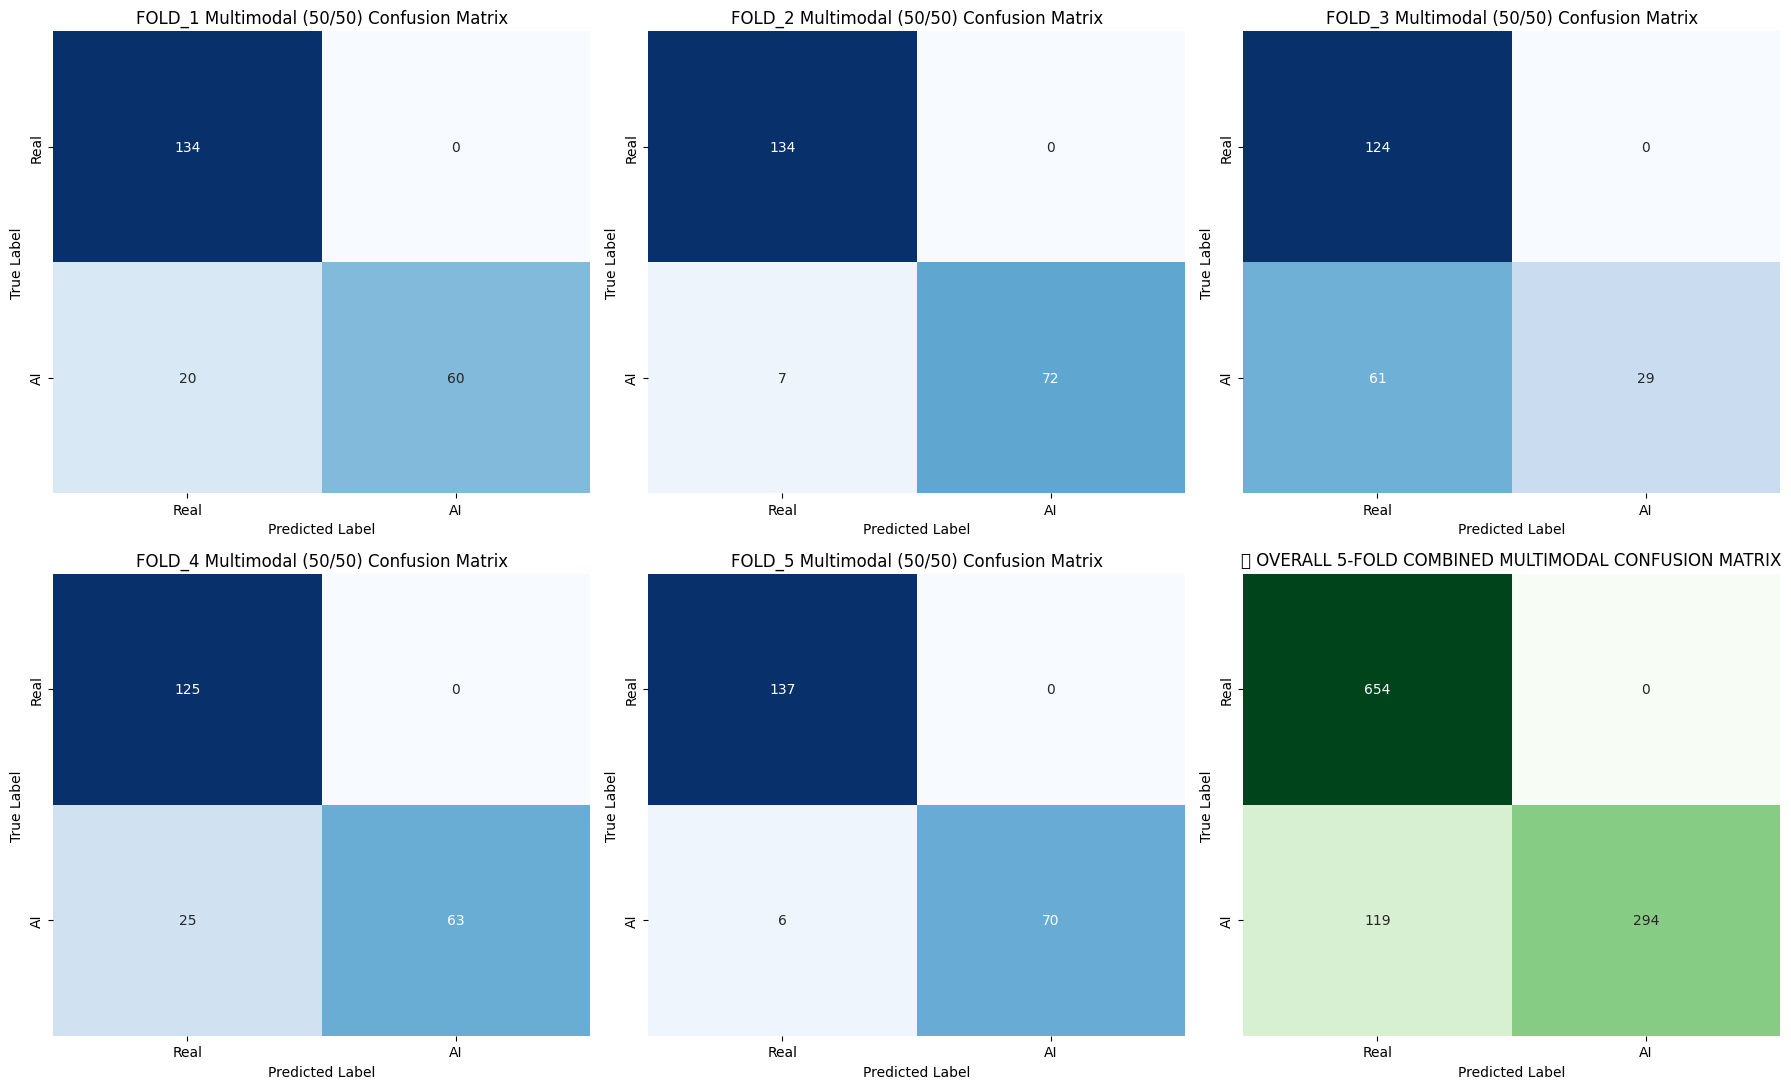

In [11]:
# 10. Plot 5-Fold Subplot Heatmaps & Master Out-of-Fold Multimodal Confusion Matrix
if fold_confusion_matrices:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()
    
    fold_names = list(fold_confusion_matrices.keys())
    for idx, f_name in enumerate(fold_names):
        sns.heatmap(fold_confusion_matrices[f_name], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                    xticklabels=CLASSES, yticklabels=CLASSES)
        axes[idx].set_title(f"{f_name.upper()} Multimodal (50/50) Confusion Matrix")
        axes[idx].set_xlabel("Predicted Label")
        axes[idx].set_ylabel("True Label")
        
    # Master Combined OOF Confusion Matrix
    cm_master = confusion_matrix(oof_targets, oof_preds, labels=[0, 1])
    sns.heatmap(cm_master, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[5],
                xticklabels=CLASSES, yticklabels=CLASSES)
    axes[5].set_title("🏆 OVERALL 5-FOLD COMBINED MULTIMODAL CONFUSION MATRIX")
    axes[5].set_xlabel("Predicted Label")
    axes[5].set_ylabel("True Label")
    
    plt.tight_layout()
    plt.show()


In [12]:
# 11. Report 5-Fold Mean +- Std Multimodal Paper Metrics
if fold_metrics:
    df_m = pd.DataFrame(fold_metrics)
    acc_m, acc_s = df_m["Accuracy"].mean(), df_m["Accuracy"].std()
    prec_m, prec_s = df_m["Precision"].mean(), df_m["Precision"].std()
    rec_m, rec_s = df_m["Recall"].mean(), df_m["Recall"].std()
    f1_m, f1_s = df_m["Macro_F1"].mean(), df_m["Macro_F1"].std()
    
    print("===============================================================")
    print("🏆 5-FOLD MULTIMODAL (50/50) LATE FUSION CROSS-VALIDATION SUMMARY")
    print("===============================================================")
    print(df_m.to_string(index=False))
    print("---------------------------------------------------------------")
    print(f"📌 Overall 5-Fold Mean Accuracy:   {acc_m:.4f} ± {acc_s:.4f} ({acc_m*100:.2f}%)")
    print(f"📌 Overall 5-Fold Mean Precision:  {prec_m:.4f} ± {prec_s:.4f} ({prec_m*100:.2f}%)")
    print(f"📌 Overall 5-Fold Mean Recall:     {rec_m:.4f} ± {rec_s:.4f} ({rec_m*100:.2f}%)")
    print(f"📌 Overall 5-Fold Mean Macro F1:  {f1_m:.4f} ± {f1_s:.4f} ({f1_m*100:.2f}%)")
    print("===============================================================")
    
    print("\n===============================================================")
    print("📋 OVERALL MULTIMODAL OUT-OF-FOLD CLASSIFICATION REPORT")
    print("===============================================================")
    print(classification_report(oof_targets, oof_preds, target_names=CLASSES, digits=4))


🏆 5-FOLD MULTIMODAL (50/50) LATE FUSION CROSS-VALIDATION SUMMARY
  Fold  Accuracy  Precision   Recall  Macro_F1
fold_1  0.906542   0.935065 0.875000  0.893849
fold_2  0.967136   0.975177 0.955696  0.964094
fold_3  0.714953   0.835135 0.661111  0.644992
fold_4  0.882629   0.916667 0.857955  0.871764
fold_5  0.971831   0.979021 0.960526  0.968738
---------------------------------------------------------------
📌 Overall 5-Fold Mean Accuracy:   0.8886 ± 0.1044 (88.86%)
📌 Overall 5-Fold Mean Precision:  0.9282 ± 0.0584 (92.82%)
📌 Overall 5-Fold Mean Recall:     0.8621 ± 0.1215 (86.21%)
📌 Overall 5-Fold Mean Macro F1:  0.8687 ± 0.1321 (86.87%)

📋 OVERALL MULTIMODAL OUT-OF-FOLD CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.8461    1.0000    0.9166       654
          AI     1.0000    0.7119    0.8317       413

    accuracy                         0.8885      1067
   macro avg     0.9230    0.8559    0.8741      1067
weighted avg     0.9056   

In [13]:
# 12. Section 10: Independent Held-Out Multimodal Test Set Evaluation (testReal.zip & testAI.zip)
ZIP_TEST_PATHS = {
    "Real": [
        os.path.join(DRIVE_DATASET_DIR, "Real", "testReal.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testReal.zip")
    ],
    "AI": [
        os.path.join(DRIVE_DATASET_DIR, "AI", "testAI.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testAI.zip")
    ]
}

LOCAL_RAW_TEST_DIR = "/content/dataset_raw_test"
LOCAL_AUDIO_TEST_DIR = "/content/dataset_audio_test_16k"
os.makedirs(LOCAL_RAW_TEST_DIR, exist_ok=True)
os.makedirs(LOCAL_AUDIO_TEST_DIR, exist_ok=True)

# Unzip Independent Test Archives
for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    candidates = ZIP_TEST_PATHS.get(cls, [])
    found_zip = None
    for p in candidates:
        if os.path.exists(p):
            found_zip = p
            break
    if found_zip:
        if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
            print(f"⏭️ Target test directory '{extract_target}' already exists. Skipping unzip.")
        else:
            unzip_file(found_zip, extract_target)
    else:
        print(f"⚠️ Warning: Could not locate test zip for {cls} at candidates: {candidates}")

# Pre-extract 16kHz Mono Audio Files for Test Videos
for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_TEST_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    if not os.path.exists(cls_raw_dir):
        continue
    video_files = glob.glob(os.path.join(cls_raw_dir, "**", "*.mp4"), recursive=True)
    for vid in tqdm(video_files, desc=f"Test Audio Extraction [{cls}]"):
        v_stem = Path(vid).stem
        out_wav = os.path.join(cls_audio_dir, f"{v_stem}.wav")
        if os.path.exists(out_wav) and os.path.getsize(out_wav) > 1000:
            continue
        extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)

test_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    video_files = glob.glob(os.path.join(cls_dir, "**", "*.mp4"), recursive=True)
    for vf in video_files:
        v_stem = Path(vf).stem
        test_video_samples.append((vf, label_idx, v_stem))

print(f"\n===============================================================")
print(f"🧪 EVALUATING 5-FOLD MULTIMODAL ENSEMBLE ON HELD-OUT TEST SET ({len(test_video_samples)} Samples)")
print(f"===============================================================")


⏭️ Target test directory '/content/dataset_raw_test/Real' already exists. Skipping unzip.
⏭️ Target test directory '/content/dataset_raw_test/AI' already exists. Skipping unzip.


Test Audio Extraction [AI]: 100%|██████████| 122/122 [00:00<00:00, 66749.95it/s]


🧪 EVALUATING 5-FOLD MULTIMODAL ENSEMBLE ON HELD-OUT TEST SET (312 Samples)


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_1] Test Ensemble Infer:   0%|          | 0/312 [00:00<?, ?it/s]/tmp/ipykernel_105905/3080555083.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_105905/3080555083.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[fold_1] Test Ensemble Infer: 100%|██████████| 312/312 [03:43<00:00,  1.40it/s]


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_5] Test Ensemble Infer: 100%|██████████| 312/312 [03:43<00:00,  1.40it/s]


✅ Evaluated 5 Multimodal Fold Ensembles!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


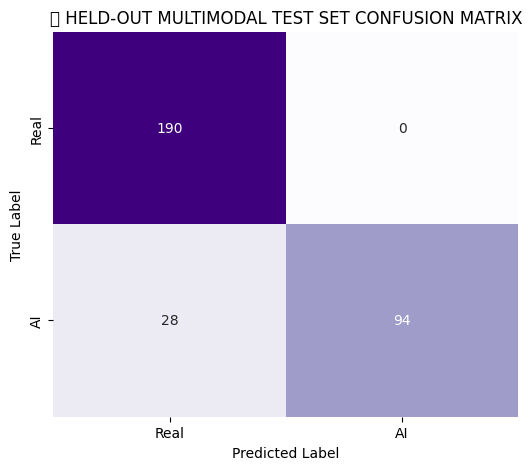


📋 INDEPENDENT HELD-OUT MULTIMODAL TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.8716    1.0000    0.9314       190
          AI     1.0000    0.7705    0.8704       122

    accuracy                         0.9103       312
   macro avg     0.9358    0.8852    0.9009       312
weighted avg     0.9218    0.9103    0.9075       312



In [14]:
# 13. Run 5-Fold Multimodal Ensemble Inference on Held-Out Test Set (Sequential Fold Evaluation to save VRAM)
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

y_true_test = []
sample_v_probs = {idx: [] for idx in range(len(test_video_samples))}
sample_a_probs = {idx: [] for idx in range(len(test_video_samples))}

for idx, (vf, true_label, stem) in enumerate(test_video_samples):
    y_true_test.append(true_label)

active_folds_count = 0
for fold_name in kfold_splits.keys():
    v_p = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
    a_p = os.path.join(MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
    if os.path.exists(v_p) and os.path.exists(a_p):
        active_folds_count += 1
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
        vm = AutoModelForImageClassification.from_pretrained(v_p).to(device)
        am = AutoModelForAudioClassification.from_pretrained(a_p).to(device)
        vm.eval()
        am.eval()
        
        for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc=f"[{fold_name}] Test Ensemble Infer")):
            wav_path = os.path.join(LOCAL_AUDIO_TEST_DIR, CLASSES[true_label], f"{stem}.wav")
            pv = predict_video_ai_prob(vf, vm)
            pa = predict_audio_ai_prob(wav_path, am)
            sample_v_probs[idx].append(pv)
            sample_a_probs[idx].append(pa)
            
        del vm, am
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"✅ Evaluated {active_folds_count} Multimodal Fold Ensembles!")

y_pred_test = []
if active_folds_count > 0 and len(test_video_samples) > 0:
    for idx in range(len(test_video_samples)):
        p_vid_ens = np.mean(sample_v_probs[idx])
        p_aud_ens = np.mean(sample_a_probs[idx])
        p_multimodal = (0.5 * p_vid_ens) + (0.5 * p_aud_ens)
        pred_lbl = 1 if p_multimodal >= 0.5 else 0
        y_pred_test.append(pred_lbl)
        
    # Plot Independent Multimodal Test Set Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm_test = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title("🧪 HELD-OUT MULTIMODAL TEST SET CONFUSION MATRIX")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.show()
    
    print("\n===============================================================")
    print("📋 INDEPENDENT HELD-OUT MULTIMODAL TEST SET CLASSIFICATION REPORT")
    print("===============================================================")
    print(classification_report(y_true_test, y_pred_test, target_names=CLASSES, digits=4))
else:
    print("ℹ️ Audio test samples or fine-tuned fold checkpoints not ready for test evaluation.")


In [15]:
# 14. Single Video Multimodal Prediction Helper Function
def predict_multimodal_single_video(video_path, weight_video=0.5, weight_audio=0.5):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")
    v_stem = Path(video_path).stem
    temp_wav = f"/content/temp_{v_stem}.wav"
    extract_audio_from_video(video_path, temp_wav, target_sr=SAMPLE_RATE)
    
    v_probs = [predict_video_ai_prob(video_path, vm) for vm in ensemble_video_models]
    a_probs = [predict_audio_ai_prob(temp_wav, am) for am in ensemble_audio_models]
    
    p_vid = float(np.mean(v_probs))
    p_aud = float(np.mean(a_probs))
    p_multimodal = (weight_video * p_vid) + (weight_audio * p_aud)
    
    pred_label = "AI" if p_multimodal >= 0.5 else "Real"
    confidence = max(p_multimodal, 1.0 - p_multimodal)
    
    print(f"🎬 Input Video: {video_path}")
    print(f"🏆 5-Fold Multimodal Ensemble Prediction: {pred_label} ({confidence*100:.2f}% Confidence)")
    print(f"📊 Video P(AI): {p_vid*100:.2f}% | Audio P(AI): {p_aud*100:.2f}% | Multimodal P(AI): {p_multimodal*100:.2f}%")
    
    if os.path.exists(temp_wav):
        os.remove(temp_wav)
        
    return {
        "video_path": video_path,
        "prediction": pred_label,
        "confidence": confidence,
        "p_video_ai": p_vid,
        "p_audio_ai": p_aud,
        "p_multimodal_ai": p_multimodal
    }
